In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

# Configure logger to ignore everything to avoid cluttering the output
import logging
logging.getLogger().setLevel(logging.WARNING)

import dotenv # load env vars from .env
dotenv.load_dotenv()

from openai import OpenAI
import dotenv  
import os   

dotenv.load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=OPENAI_API_KEY)

/Users/admin/repos/geneforge


In [2]:
import random
from src.examples.agent.maximize_promoter_strength import MaximizePromoterStrengthWorkflow
OUTPUT_DIR = "datasets/maximize_promoter_strength_dataset"

def get_promoters():
    from src.library.cello_library import CelloLibrary
    library = CelloLibrary()
    library.select_library("Eco1C1G1T1")
    promoters = {collection["name"]: collection["dnasequence"] for collection in library.user_constraints if collection["collection"] == "parts" and collection["type"] == "promoter"}
    return promoters

promoter_pool = get_promoters()
promoter_names = list(promoter_pool.keys())
random.shuffle(promoter_names)

/Users/admin/repos/geneforge/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:library_manager:Library manager initialized. Found 5 potential libraries.


In [ ]:
from sklearn.model_selection import train_test_split
from src.examples.agent.egc_problem1p1 import EGCProblem1p1Workflow
from src.examples.agent.maximize_promoter_strength import MaximizePromoterStrengthWorkflow

promoter_sequences = list(promoter_pool.keys())
print(promoter_sequences)

['pAmtR', 'pBM3R1', 'pBetI', 'pAmeR', 'pHlyIIR', 'pIcaRA', 'pLitR', 'pLmrA', 'pPhlF', 'pQacR', 'pPsrA', 'pSrpR']


#### Run the workflow to get the metrics over several runs

In [ ]:
from src.adapters.art_adapter import ArtAdapter
import art
from art.gather import gather_trajectory_groups
from src.examples.agent.egc_problem1p1 import EGCProblem1p1Workflow
from src.examples.agent.maximize_promoter_strength import MaximizePromoterStrengthWorkflow

config = {
    "rollouts_per_group": 3,
    "max_rounds": 30,
}

step = 0
groups = tuple(
    art.TrajectoryGroup(
        (
            ArtAdapter(
                MaximizePromoterStrengthWorkflow(
                    example_name=f"maximize_promoter_strength_workflow_test_{promoter_sequence}",
                    promoter_sequence=promoter_sequence,
                    use_reasoning_model=True,
                ),
                step=step,
            ).rollout(max_rounds=config["max_rounds"])
            for _ in range(config["rollouts_per_group"])
        )
    )
    for promoter_sequence in promoter_sequences[:3]
)

# run them
max_promoter_strength_groups = await gather_trajectory_groups(
    groups,
    pbar_desc="gather",
    max_exceptions=18,
)
print(len(max_promoter_strength_groups))

#### Compute some statistics, such as the range that will help us define a reward function

8
8


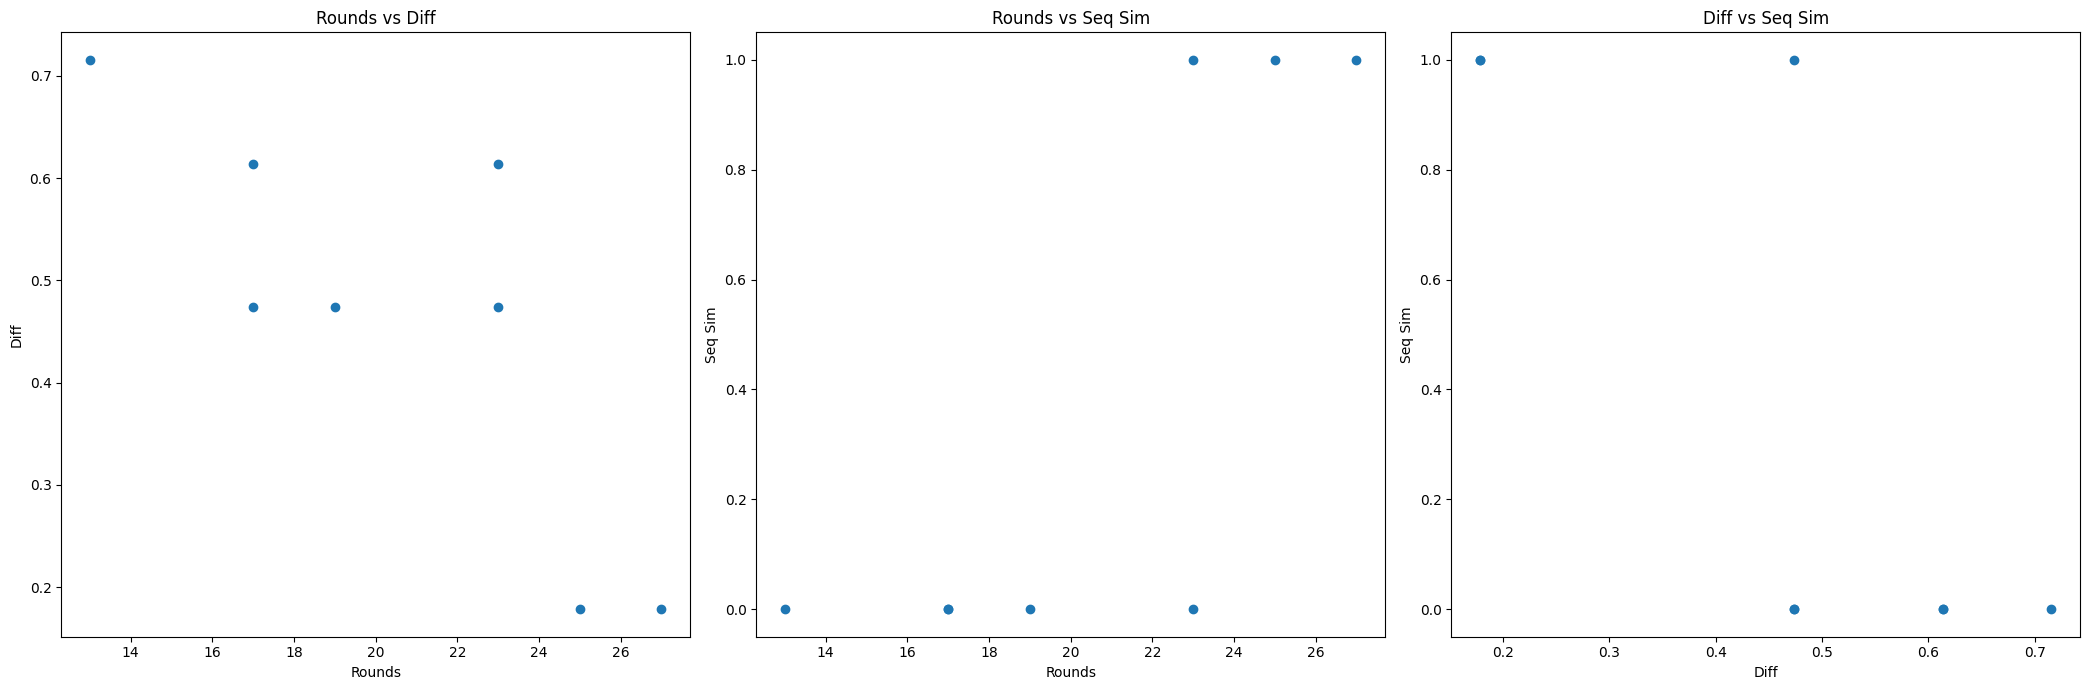

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

all_max_promoter_strength_metrics = []

# Get the metrics and scores for each trajectory
trajectories_scores = []
for group in max_promoter_strength_groups:
    for trajectory in group.trajectories:
        all_max_promoter_strength_metrics.append(trajectory.metrics)
        trajectories_scores.append(trajectory.reward)

removed_metrics_indicies = [i for i in range(len(all_max_promoter_strength_metrics)) if not all_max_promoter_strength_metrics[i]]
all_max_promoter_strength_metrics = [m for i, m in enumerate(all_max_promoter_strength_metrics) if i not in removed_metrics_indicies]

print(len(all_max_promoter_strength_metrics))


# show an interactive 3-d scatter plot of the metrics
df = pd.DataFrame(all_max_promoter_strength_metrics)

fig, axs = plt.subplots(1, 3, figsize=(21, 7))

# First subplot
axs[0].scatter(df['num_rounds'], df['difference'])
axs[0].set_xlabel('Rounds')
axs[0].set_ylabel('Diff')
axs[0].set_title('Rounds vs Diff')

# Second subplot
axs[1].scatter(df['num_rounds'], df['sequence_similarity'])
axs[1].set_xlabel('Rounds')
axs[1].set_ylabel('Seq Sim')
axs[1].set_title('Rounds vs Seq Sim')

# Third subplot
axs[2].scatter(df['difference'], df['sequence_similarity'])
axs[2].set_xlabel('Diff')
axs[2].set_ylabel('Seq Sim')
axs[2].set_title('Diff vs Seq Sim')

plt.tight_layout()
plt.show()

In [59]:
# get the scale difference between each metric
import statistics
import json

diff_mean = statistics.mean([metric['difference'] for metric in all_max_promoter_strength_metrics])
num_rounds_mean = statistics.mean([metric['num_rounds'] for metric in all_max_promoter_strength_metrics])
sequence_similarity_mean = statistics.mean([metric['sequence_similarity'] for metric in all_max_promoter_strength_metrics])

# compute weights such that these means sum to 1
weights = {
    "difference": diff_mean / (diff_mean + num_rounds_mean + sequence_similarity_mean),
    "num_rounds": num_rounds_mean / (diff_mean + num_rounds_mean + sequence_similarity_mean),
    "sequence_similarity": sequence_similarity_mean / (diff_mean + num_rounds_mean + sequence_similarity_mean)
}
weights

{'difference': 0.021787418910884617,
 'num_rounds': 0.9606398999917061,
 'sequence_similarity': 0.017572681097409257}

In [60]:
# Now we can compute the score for each metric
manual_scores = []
for metric in all_max_promoter_strength_metrics:
    score = metric['difference'] * weights['difference'] - metric['num_rounds'] * weights['num_rounds'] + metric['sequence_similarity'] * weights['sequence_similarity']
    print(json.dumps(metric, indent=4))
    print(score)
    print("--------------------------------")
    manual_scores.append(score)

# compute the mean of the scores
mean_score = statistics.mean(manual_scores)

{
    "answer_strength": 2.344359730816177,
    "reference_strength": 2.1661176600132057,
    "difference": 0.1782420708029715,
    "reference_class": 5,
    "answer_class": 7,
    "sequence_similarity": 1.0,
    "num_rounds": 27
}
-25.915821184014526
--------------------------------
{
    "answer_strength": 2.6395966440378404,
    "reference_strength": 2.1661176600132057,
    "difference": 0.47347898402463473,
    "reference_class": 5,
    "answer_class": 10,
    "sequence_similarity": 1.0,
    "num_rounds": 23
}
-22.066829133741386
--------------------------------
{
    "answer_strength": 2.344359730816177,
    "reference_strength": 2.1661176600132057,
    "difference": 0.1782420708029715,
    "reference_class": 5,
    "answer_class": 7,
    "sequence_similarity": 1.0,
    "num_rounds": 25
}
-23.994541384031113
--------------------------------
{
    "answer_strength": 2.6395966440378404,
    "reference_strength": 2.1661176600132057,
    "difference": 0.47347898402463473,
    "referen

In [43]:
# We need to clean up the system prompt to avoid OpenAI complaining about violating the rules
from src.prompt_manager import get_system_prompt

system_prompt = get_system_prompt()

replaced = 0
for group in max_promoter_strength_groups:
    for trajectory in group.trajectories:
        for message in trajectory.messages_and_choices:
            if message.get("role", None) == "system":
                message["content"] = message["content"].replace(system_prompt, "You are genetic engineering assistant that can answer questions using tools to help you.")
                replaced += 1

print(f"Replaced {replaced} system prompts")

Replaced 9 system prompts


### Let's get some AI scores for comparison

In [ ]:
from art.rewards import ruler
from art.rewards import ruler_score_group

from src.examples.agent.maximize_promoter_strength import GRADING_RUBRIC

print(GRADING_RUBRIC)
judged_groups = []
ai_scores = []
for i, group in enumerate(max_promoter_strength_groups):
    try:
        max_promoter_strength_groups_judged = await ruler_score_group(group, 
                                                                  "openai/o4-mini", 
                                                                  rubric=GRADING_RUBRIC,
                                                                  debug=True)
        judged_groups.append(max_promoter_strength_groups_judged)
        ai_scores += [trajectory.reward for trajectory in max_promoter_strength_groups_judged.trajectories]
    except Exception as e:
        print(f"Error scoring group {i}: {e}")

judged_groups
ai_scores

In [48]:
import json

for metrics, ai_score, manual_score in zip(metrics, ai_scores, manual_scores):
    print(f"Metrics: {json.dumps(metrics, indent=4)}")
    print(f"AI Score: {ai_score}")
    print(f"Manual Score: {manual_score}")
    print("--------------------------------")

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(1, 2, 1)
plt.bar(range(len(manual_scores)), manual_scores)
plt.title("Manual Scores")
plt.subplot(1, 2, 2)
plt.bar(range(len(ai_scores)), [score.score for score in ai_scores])
plt.title("AI Scores")
plt.show()

In [ ]:
# plot each metric against the score
import matplotlib.pyplot as plt

plt.scatter(metrics, ai_scores)
plt.xlabel('Metric')
plt.ylabel('Score')
plt.show()